## 🛠️ Preparación de los Datos

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/justme088/TelecomX_parte2_Latam_AluraLATAM_G9/refs/heads/main/datos_tratados.csv"

datos = pd.read_csv(url)
datos.head(3)

# Yes: 1, No: 0

,customerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,CuentasDiarias,Servicios_Totales
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,Yes,No,One_year,1,Mailed_check,65.6,593.30,2.19,3
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,0,Mailed_check,59.9,542.40,2.00,2
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber_optic,...,No,No,No,Month-to-month,1,Electronic_check,73.9,280.85,2.46,1


In [57]:
# Inspección de valores únicos por columna
for columna in datos.columns:
    print(f"Columna: {columna}")
    print(f"Número de valores únicos: {datos[columna].nunique()}")
    print(f"Valores únicos: {datos[columna].unique()[:10]}") # Mostramos los primeros 10 para no saturar
    print("-" * 30)

Columna: customerID
Número de valores únicos: 7043
Valores únicos: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' '0013-EXCHZ'
 '0013-MHZWF' '0013-SMEOE' '0014-BMAQU' '0015-UOCOJ' '0016-QLJIS']
------------------------------
Columna: Churn
Número de valores únicos: 2
Valores únicos: [0 1]
------------------------------
Columna: Gender
Número de valores únicos: 2
Valores únicos: ['Female' 'Male']
------------------------------
Columna: SeniorCitizen
Número de valores únicos: 2
Valores únicos: [0 1]
------------------------------
Columna: Partner
Número de valores únicos: 2
Valores únicos: [1 0]
------------------------------
Columna: Dependents
Número de valores únicos: 2
Valores únicos: [1 0]
------------------------------
Columna: Tenure
Número de valores únicos: 73
Valores únicos: [ 9  4 13  3 71 63  7 65 54 72]
------------------------------
Columna: PhoneService
Número de valores únicos: 2
Valores únicos: [1 0]
------------------------------
Columna: MultipleLines
Número de v

In [58]:
# Definición de las columnas a eliminar según el análisis de relevancia
columnas_descarte = ['customerID', 'Gender', 'PhoneService', 'CuentasDiarias']

# Ejecución de la limpieza en el dataframe 'datos'
datos = datos.drop(columns=columnas_descarte)

# Verificación de la nueva estructura del dataset
print(f"Columnas eliminadas con éxito: {columnas_descarte}")
print(f"Dimensiones actuales del dataset: {datos.shape}")
print("-" * 30)
print(f"Columnas restantes para el modelo: \n{datos.columns.tolist()}")

Columnas eliminadas con éxito: ['customerID', 'Gender', 'PhoneService', 'CuentasDiarias']
Dimensiones actuales del dataset: (7043, 19)
------------------------------
Columnas restantes para el modelo: 
['Churn', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'ChargesMonthly', 'ChargesTotal', 'Servicios_Totales']


In [59]:
# Identificar columnas categóricas con más de 2 niveles
# Nota: 'Churn' es nuestra variable objetivo, esa ya es numérica (0, 1)
columnas_nominales = ['InternetService', 'Contract', 'PaymentMethod',
                      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                      'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

# Aplicar One-Hot Encoding
# Esto creará columnas como InternetService_Fiber_optic, Contract_Two_year, etc.
datos_encoded = pd.get_dummies(datos, columns=columnas_nominales, drop_first=False)

# Verificación de la transformación
print(f"Dimensiones antes del encoding: {datos.shape}")
print(f"Dimensiones después del encoding: {datos_encoded.shape}")
print("\nNuevas columnas generadas:")
print(datos_encoded.columns.tolist())

# Mostrar las primeras filas del nuevo dataframe
datos_encoded.head()

Dimensiones antes del encoding: (7043, 19)
Dimensiones después del encoding: (7043, 40)

Nuevas columnas generadas:
['Churn', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'PaperlessBilling', 'ChargesMonthly', 'ChargesTotal', 'Servicios_Totales', 'InternetService_DSL', 'InternetService_Fiber_optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One_year', 'Contract_Two_year', 'PaymentMethod_Bank_transfer_(automatic)', 'PaymentMethod_Credit_card_(automatic)', 'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check', 'OnlineSecurity_No', 'OnlineSecurity_No_internet_service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No_internet_service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No_internet_service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No_internet_service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No_internet_service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No_internet_service', 'Strea

,Churn,SeniorCitizen,Partner,Dependents,Tenure,PaperlessBilling,ChargesMonthly,ChargesTotal,Servicios_Totales,InternetService_DSL,...,TechSupport_Yes,StreamingTV_No,StreamingTV_No_internet_service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No_internet_service,StreamingMovies_Yes,MultipleLines_No,MultipleLines_No_phone_service,MultipleLines_Yes
0,0,0,1,1,9,1,65.6,593.30,3,True,...,True,False,False,True,True,False,False,True,False,False
1,0,0,0,0,9,0,59.9,542.40,2,True,...,False,True,False,False,False,False,True,False,False,True
2,1,0,0,0,4,1,73.9,280.85,1,False,...,False,True,False,False,True,False,False,True,False,False
3,1,1,1,0,13,1,98.0,1237.85,4,False,...,False,False,False,True,False,False,True,True,False,False
4,1,1,1,0,3,1,83.9,267.40,2,False,...,True,False,False,True,True,False,False,True,False,False


In [60]:
# Cálculo de la proporción de la variable objetivo
print("Recuento absoluto de Churn:")
print(datos['Churn'].value_counts())

print("\nProporción porcentual:")
print(datos['Churn'].value_counts(normalize=True) * 100)

Recuento absoluto de Churn:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporción porcentual:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [61]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Definir nuestras variables X (características) y y (objetivo)
# Usaremos el dataframe 'datos_encoded' que generamos en el paso anterior
X = datos_encoded.drop('Churn', axis=1)
y = datos_encoded['Churn']

# Configurar SMOTE
smote = SMOTE(random_state=42)

# Generar los datos balanceados
X_resampled, y_resampled = smote.fit_resample(X, y)

# Verificar los nuevos resultados
print(f"Distribución original: {Counter(y)}")
print(f"Distribución tras SMOTE: {Counter(y_resampled)}")

Distribución original: Counter({0: 5174, 1: 1869})
Distribución tras SMOTE: Counter({0: 5174, 1: 5174})


In [62]:
from sklearn.model_selection import train_test_split

# Dividimos los datos balanceados (X_resampled, y_resampled)
# Reservamos el 20% para la prueba final (test)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Muestras de prueba: {len(X_test)}")

Muestras de entrenamiento: 8278
Muestras de prueba: 2070


In [63]:
from sklearn.preprocessing import StandardScaler

# Instanciar el escalador
scaler = StandardScaler()

# Ajustar y transformar los datos de ENTRENAMIENTO
# Importante: No escalamos la variable objetivo 'y'
X_train_scaled = scaler.fit_transform(X_train)

# Transformar los datos de PRUEBA (usando el ajuste del entrenamiento)
X_test_scaled = scaler.transform(X_test)

print("¡Datos estandarizados con éxito!")
print(f"Media aproximada de X_train_scaled: {X_train_scaled.mean():.2f}")
print(f"Desviación estándar de X_train_scaled: {X_train_scaled.std():.2f}")

¡Datos estandarizados con éxito!
Media aproximada de X_train_scaled: -0.00
Desviación estándar de X_train_scaled: 1.00


## 🎯 Correlación y Selección de Variables

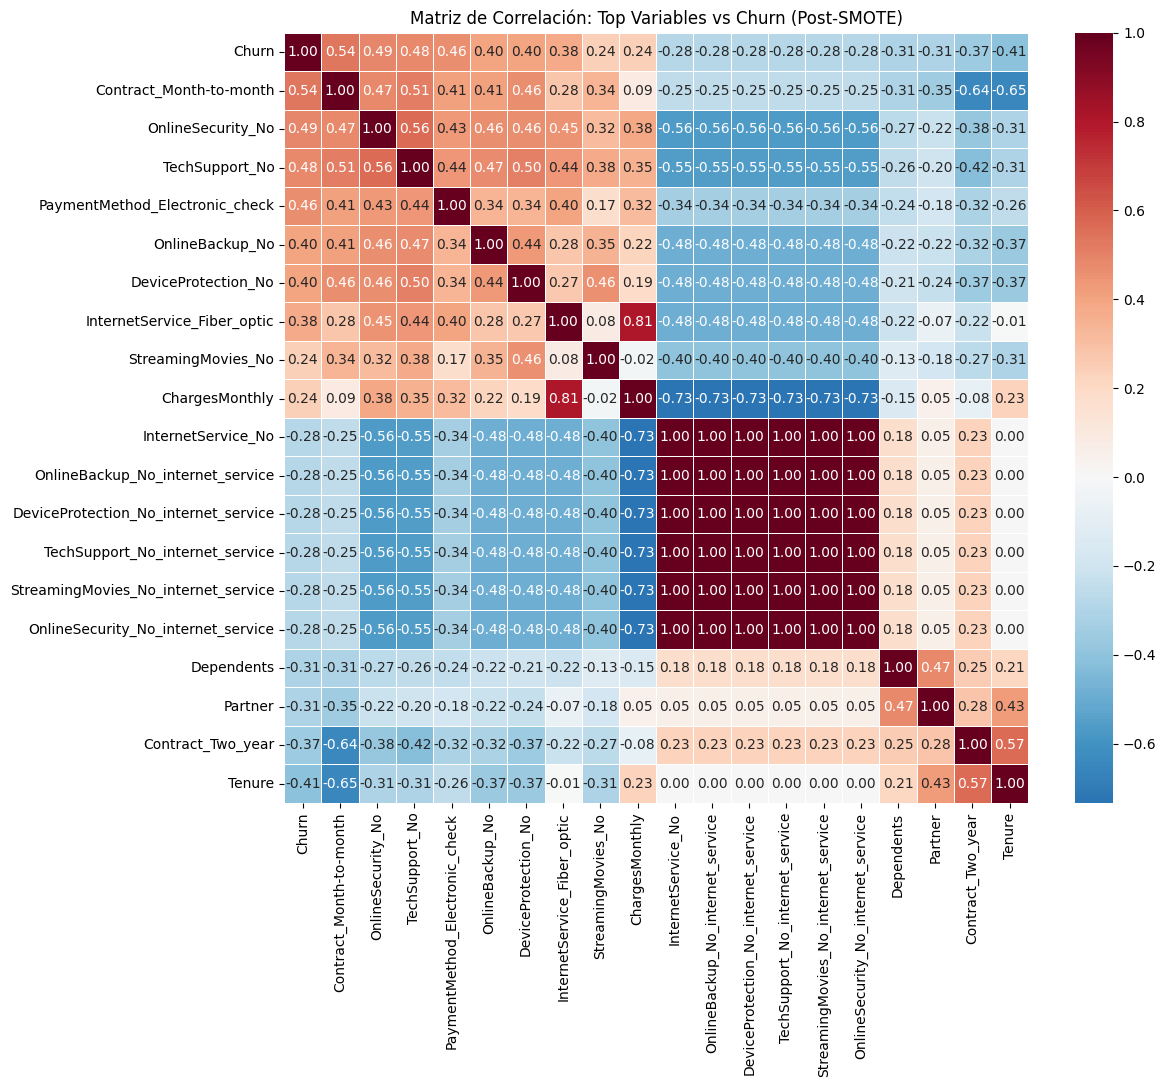

In [64]:
# Creamos el DataFrame desde los datos balanceados
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['Churn'] = y_resampled

# Calculamos todas las correlaciones con la variable objetivo
correlaciones = df_resampled.corr()['Churn'].sort_values(ascending=False)

# Seleccionamos las 10 más positivas y las 10 más negativas usando pd.concat
top_positivas = correlaciones.head(10)
top_negativas = correlaciones.tail(10)
top_corr_series = pd.concat([top_positivas, top_negativas])

# Graficamos
plt.figure(figsize=(12, 10))
sns.heatmap(df_resampled[top_corr_series.index].corr(),
            annot=True,
            cmap='RdBu_r',
            center=0,
            fmt='.2f',
            linewidths=0.5)

plt.title('Matriz de Correlación: Top Variables vs Churn (Post-SMOTE)')
plt.show()

In [65]:
# La matriz muestra una colinealidad perfecta (1.00) entre varias categorías de "No internet service".
# Esto es un hallazgo técnico clave: el modelo recibirá información redundante si mantenemos todas estas columnas,
# por lo que es un buen momento para simplificarlas.

# Identificar columnas de "No internet service" (que son redundantes)
columnas_redundantes = [col for col in X_resampled.columns if 'No_internet_service' in col]

# Eliminarlas del set de entrenamiento y prueba
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns).drop(columns=columnas_redundantes)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns).drop(columns=columnas_redundantes)

print(f"Columnas eliminadas por redundancia: {len(columnas_redundantes)}")

# Entrenamiento de modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Instanciar
log_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

# Entrenar
log_model.fit(X_train_final, y_train)
rf_model.fit(X_train_final, y_train)

# Predecir
y_pred_log = log_model.predict(X_test_final)
y_pred_rf = rf_model.predict(X_test_final)

print("\nEvaluación: Regresión Logística")
print(classification_report(y_test, y_pred_log))

print("\nEvaluación: Random Forest")
print(classification_report(y_test, y_pred_rf))


Columnas eliminadas por redundancia: 6

Evaluación: Regresión Logística
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1027
           1       0.87      0.83      0.85      1043

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.86      0.85      0.85      2070


Evaluación: Random Forest
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1027
           1       0.87      0.83      0.85      1043

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



/tmp/ipykernel_1762/3751401079.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Tenure', data=datos, palette='magma')


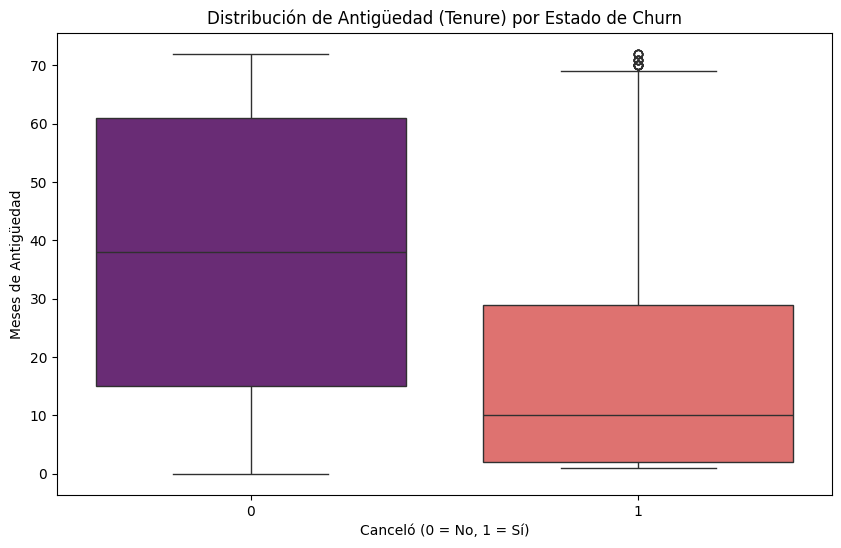

In [66]:
# Tiempo de Contrato (Tenure) × Cancelación

plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Tenure', data=datos, palette='magma')
plt.title('Distribución de Antigüedad (Tenure) por Estado de Churn')
plt.xlabel('Canceló (0 = No, 1 = Sí)')
plt.ylabel('Meses de Antigüedad')
plt.show()

/tmp/ipykernel_1762/535159406.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(datos[datos['Churn'] == 0]['ChargesMonthly'], label='Permanecen', shade=True, color="blue")
/tmp/ipykernel_1762/535159406.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(datos[datos['Churn'] == 1]['ChargesMonthly'], label='Cancelan', shade=True, color="red")


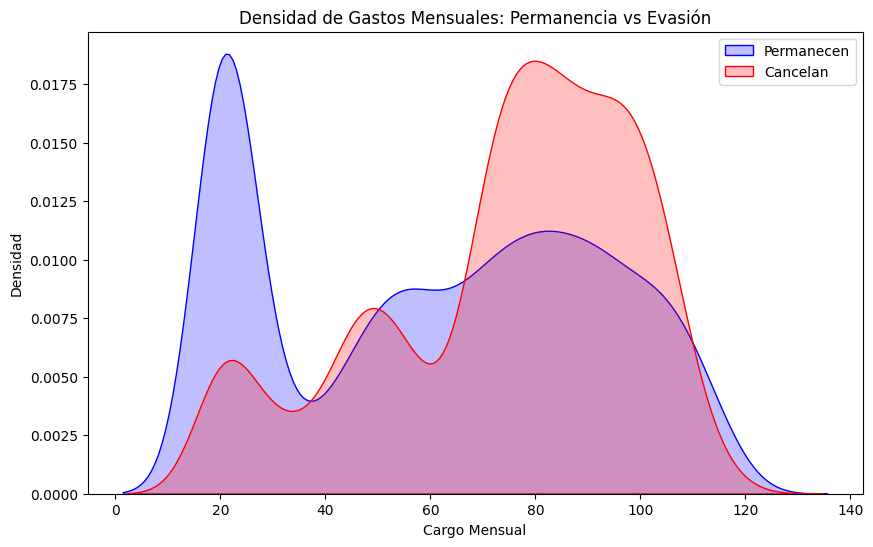

In [67]:
# Gasto Mensual (ChargesMonthly) × Cancelación
plt.figure(figsize=(10, 6))
sns.kdeplot(datos[datos['Churn'] == 0]['ChargesMonthly'], label='Permanecen', shade=True, color="blue")
sns.kdeplot(datos[datos['Churn'] == 1]['ChargesMonthly'], label='Cancelan', shade=True, color="red")
plt.title('Densidad de Gastos Mensuales: Permanencia vs Evasión')
plt.xlabel('Cargo Mensual')
plt.ylabel('Densidad')
plt.legend()
plt.show()

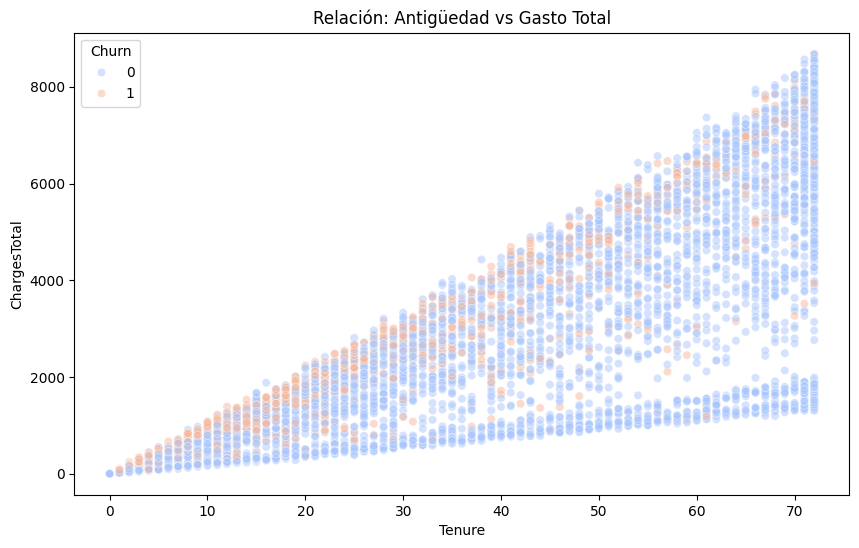

In [68]:
# Gasto Total × Antigüedad (Relación Combinada)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Tenure', y='ChargesTotal', hue='Churn', data=datos, alpha=0.5, palette='coolwarm')
plt.title('Relación: Antigüedad vs Gasto Total')
plt.show()

## 🤖 Modelado Predictivo

In [69]:
from sklearn.model_selection import train_test_split

# Separamos las características (X) de la variable objetivo (y)
# Usamos el dataframe balanceado (X_resampled, y_resampled)
X = X_resampled
y = y_resampled

# Realizamos la división: 80% Entrenamiento, 20% Prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba (Test): {X_test.shape[0]} registros")

Entrenamiento: 8278 registros
Prueba (Test): 2070 registros


In [70]:
from sklearn.linear_model import LogisticRegression

# Usamos X_train_scaled que ya teníamos preparado
modelo_logistico = LogisticRegression(random_state=42)
modelo_logistico.fit(X_train_scaled, y_train)

print("Modelo 1 (Regresión Logística) entrenado con datos normalizados.")

Modelo 1 (Regresión Logística) entrenado con datos normalizados.


In [71]:
from sklearn.ensemble import RandomForestClassifier

# Podemos usar X_train_scaled o X_train original, el resultado será casi idéntico
modelo_forest = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_forest.fit(X_train_scaled, y_train)

print("Modelo 2 (Random Forest) entrenado.")

Modelo 2 (Random Forest) entrenado.



Reporte: Regresión Logística
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1027
           1       0.87      0.83      0.85      1043

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.86      0.85      0.85      2070



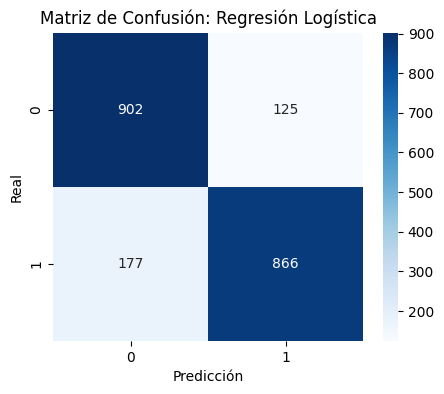


Reporte: Random Forest
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1027
           1       0.87      0.83      0.85      1043

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



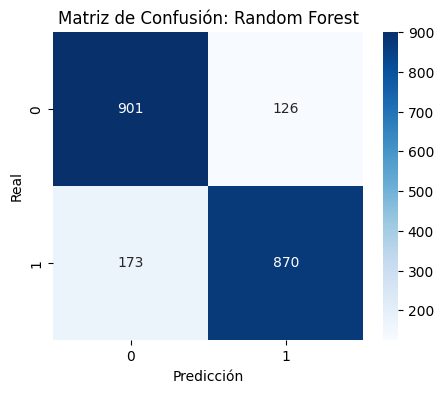

In [72]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def evaluar_modelo(modelo, X_test, y_test, nombre):
    y_pred = modelo.predict(X_test)
    print(f"\nReporte: {nombre}")
    print(classification_report(y_test, y_pred))

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.ylabel('Real')
    plt.xlabel('Predicción')
    plt.show()

# Ejecutamos para ambos
evaluar_modelo(log_model, X_test_final, y_test, "Regresión Logística")
evaluar_modelo(rf_model, X_test_final, y_test, "Random Forest")

## 📋 Interpretación y Conclusiones

/tmp/ipykernel_1762/1554707939.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=feature_importance_df.head(15), palette='viridis')


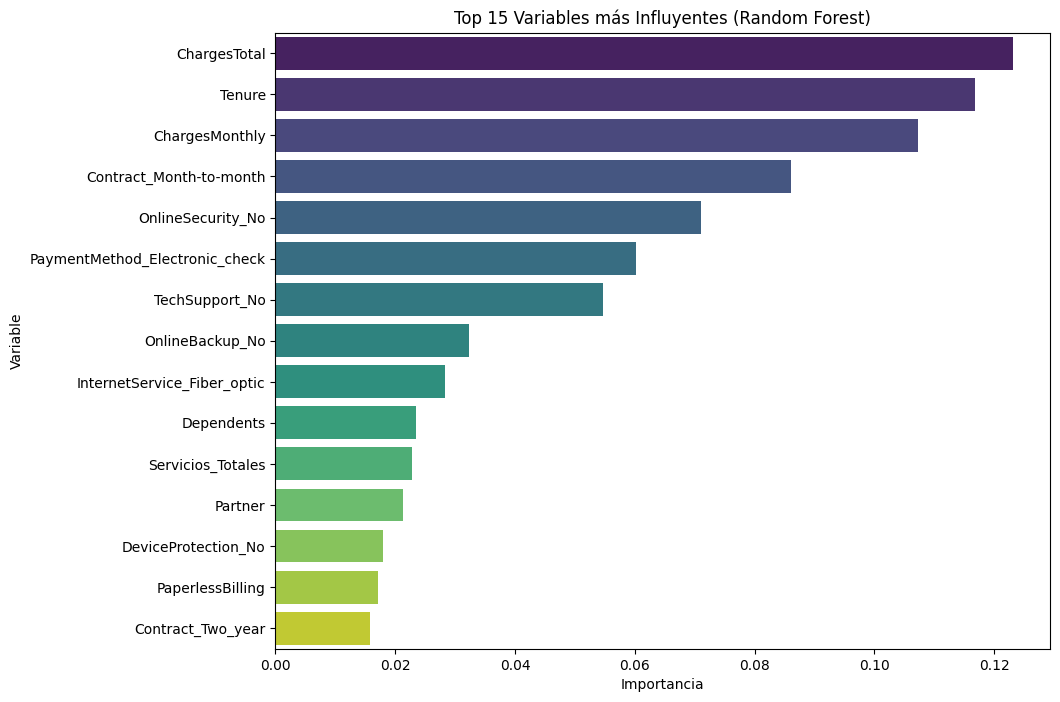

In [73]:
# Random Forest: Importancia por Impureza (Gini)
# Extraer importancias
importancias = rf_model.feature_importances_
feature_names = X_train_final.columns
feature_importance_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importancias})
feature_importance_df = feature_importance_df.sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Variables más Influyentes (Random Forest)')
plt.show()

/tmp/ipykernel_1762/3088305331.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=pd.concat([coef_df.head(7), coef_df.tail(7)]), palette='coolwarm')


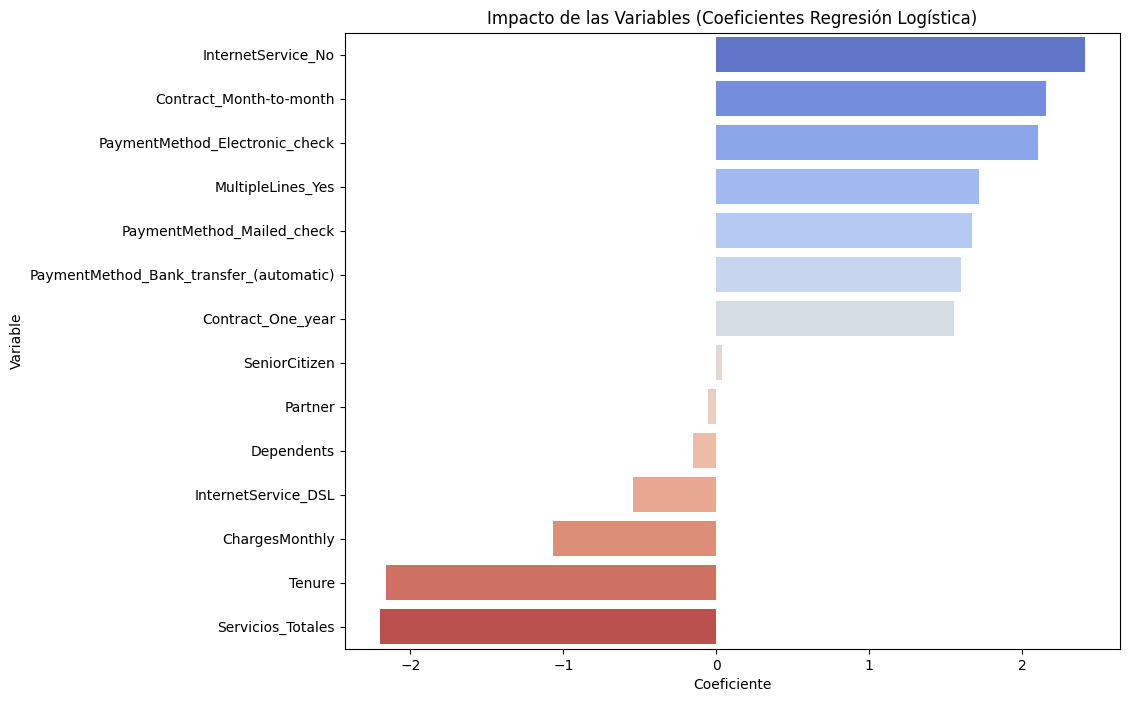

In [74]:
# Regresión Logística: Los Coeficientes
# Extraer coeficientes
coeficientes = log_model.coef_[0]
coef_df = pd.DataFrame({'Variable': feature_names, 'Coeficiente': coeficientes})
coef_df = coef_df.sort_values(by='Coeficiente', ascending=False)

# Graficar los top positivos y negativos
plt.figure(figsize=(10, 8))
sns.barplot(x='Coeficiente', y='Variable', data=pd.concat([coef_df.head(7), coef_df.tail(7)]), palette='coolwarm')
plt.title('Impacto de las Variables (Coeficientes Regresión Logística)')
plt.show()


# Informe de Análisis de Cancelación de Clientes (Churn)
## **Introducción**

El objetivo de este análisis es identificar los principales factores que influyen en la cancelación de clientes (Churn) en la empresa Telecom X y evaluar el rendimiento de distintos modelos de machine learning para predecir este comportamiento. Detectar con anticipación a los clientes con mayor probabilidad de abandono permite diseñar estrategias de retención más efectivas y reducir pérdidas económicas.

El conjunto de datos analizado presenta 7,043 registros, de los cuales 26.5% corresponden a clientes que cancelaron el servicio, mientras que 73.5% permanecen activos. Debido a este desbalance entre clases, fue necesario aplicar técnicas de balanceo de datos para mejorar el rendimiento de los modelos predictivos.

## **Preparación y procesamiento de datos**

El dataset presentaba un desbalance significativo entre clientes que permanecen y clientes que cancelan, con una proporción aproximada de 3 a 1. Este tipo de distribución puede generar problemas en modelos de clasificación, ya que un modelo podría alcanzar una alta precisión simplemente prediciendo siempre la clase mayoritaria.

Para corregir este problema se aplicó la técnica SMOTE (Synthetic Minority Over-sampling Technique), que permitió equilibrar ambas clases generando ejemplos sintéticos de clientes que cancelan. Después del balanceo, ambas clases quedaron con 5,174 registros cada una, lo que obligó a los modelos a aprender patrones reales de cancelación.

Además, se realizó la estandarización de las variables numéricas, ajustando los datos a una media cercana a 0 y desviación estándar cercana a 1. Esto mejora el desempeño de modelos como la regresión logística al evitar que variables con diferentes escalas influyan de manera desproporcionada.

También se eliminaron columnas redundantes identificadas mediante el análisis de correlación, reduciendo ruido en el modelo y evitando problemas de multicolinealidad.

## **Análisis de factores que influyen en la cancelación**

El análisis de correlación y las visualizaciones permitieron identificar los principales factores asociados con la cancelación de clientes.

**Tipo de contrato**

- El factor más influyente en la cancelación es el contrato mes a mes, con una correlación positiva alta con el churn. Este tipo de contrato permite al cliente cancelar el servicio en cualquier momento, lo que aumenta significativamente el riesgo de abandono.

- Por el contrario, los contratos de uno o dos años presentan una correlación negativa con el churn, lo que indica que actúan como un mecanismo de retención.

**Antigüedad del cliente (Tenure)**

- La antigüedad del cliente es uno de los factores más importantes para explicar la permanencia. Existe una correlación negativa significativa entre tenure y churn (-0.41).

- Los clientes que cancelan tienden a tener una antigüedad muy baja, concentrándose principalmente durante los primeros meses de servicio. En cambio, los clientes que permanecen suelen tener una permanencia superior a los 30 o 40 meses.

- Esto indica que el primer año de relación con el cliente es el periodo más crítico.

**Costo del servicio**

- El análisis de densidad muestra que la cancelación aumenta significativamente cuando los cargos mensuales superan aproximadamente los 70 dólares.

- Esto sugiere que existe un umbral de sensibilidad al precio, donde los clientes comienzan a percibir que el costo del servicio es demasiado alto en relación con el valor recibido.

- Este fenómeno se observa especialmente en clientes que utilizan servicios de fibra óptica, los cuales presentan una mayor tasa de cancelación.

**Servicios adicionales**

- La ausencia de servicios como seguridad en línea y soporte técnico también presenta una correlación positiva con el churn.

- Esto indica que los clientes que no cuentan con estos servicios adicionales tienen mayor probabilidad de cancelar, posiblemente debido a una menor integración con el ecosistema de servicios de la empresa.

**Método de pago**

- El método de pago electronic check aparece como una señal de riesgo importante, mostrando una correlación positiva con la cancelación.
- En contraste, métodos de pago automáticos como tarjetas o transferencias bancarias suelen asociarse con mayor permanencia.

## **Evaluación de modelos predictivos**

Para predecir la cancelación de clientes se entrenaron dos modelos de machine learning:

- Regresión Logística

- Random Forest

Los datos se dividieron en 80% para entrenamiento y 20% para prueba, lo que permitió evaluar la capacidad de generalización de los modelos.
| Métrica           | Regresión Logística | Random Forest |
|------------------|--------------------|---------------|
| Accuracy         | 85%                | 86%           |
| Recall (Churn)   | 83%                | 83%           |
| Precision (Churn)| 87%                | 87%           |
| F1 Score         | 0.85               | 0.86          |

El Random Forest obtuvo un rendimiento ligeramente superior, logrando identificar correctamente aproximadamente 83 de cada 100 clientes que cancelan. Además, presenta una ligera reducción en los falsos negativos, lo cual es especialmente importante en problemas de churn, ya que estos representan clientes que abandonan el servicio sin ser detectados.

El hecho de que ambos modelos tengan resultados similares indica que los patrones de cancelación en los datos son relativamente claros y consistentes.

## **Conclusiones**

El análisis permitió identificar varios factores clave que influyen en la cancelación de clientes.

- Los clientes con contratos mensuales, baja antigüedad, cargos mensuales elevados y falta de servicios adicionales presentan una mayor probabilidad de abandonar el servicio.

- Asimismo, el análisis demuestra que el primer año de relación con el cliente es el periodo de mayor riesgo, mientras que los clientes que superan los 20 meses de permanencia tienen una probabilidad significativamente menor de cancelar.

- Los modelos predictivos desarrollados muestran un desempeño sólido, siendo capaces de identificar más del 80% de los clientes que cancelarán el servicio, lo que los convierte en herramientas útiles para la implementación de estrategias de retención.

## **Estrategias de retención recomendadas**

A partir de los resultados obtenidos, se proponen las siguientes estrategias para reducir la cancelación de clientes:

1. Incentivar contratos de largo plazo y ofrecer descuentos o beneficios para que los clientes con contratos mensuales migren a contratos de uno o dos años.

2. Implementar programas de fidelización temprana creando estrategias enfocadas en clientes con menos de 12 meses de antigüedad, ya que representan el segmento con mayor riesgo de cancelación.

3. Revisar la estrategia de precios de la fibra óptica para mejorar la relación costo–valor del servicio o incluir beneficios adicionales que justifiquen su precio.

4. Promover servicios adicionales para incentivar la adopción de servicios como seguridad en línea o soporte técnico para aumentar la dependencia del cliente con el ecosistema de la empresa.

5. Fomentar métodos de pago automáticos y promover el uso de tarjetas o transferencias automáticas, que muestran mayor estabilidad en la permanencia de los clientes.